# 03-Proxy-Analysis


The goal of this analysis is to investigate whether any non-protected attributes serve as proxies for protected character-
istics - Proxy Discrimination Analysis

* Correlation analysis between non-protected attributes and gender/age
* Correlation analysis between non-protected attributes and loan approval
* Simple visual inspection / distribution checks

##### 3.1. Load of Raw Data

In [46]:
# Loading raw dataset
import json
import pandas as pd

with open("../data/raw_credit_applications.json", "r") as f:
    data = json.load(f)

df = pd.json_normalize(data)
df.head(10)

,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,...,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15T00:00:00Z,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036,...,23,0.20,31212,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,M,1992-03-31,10032,...,51,0.18,17915,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075,...,41,0.21,37909,True,NaN,vacation,3.7,59000.0,NaN,NaN
3,app_024,"[{'category': 'Fitness', 'amount': 575}]",NaN,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,1983-04-25,10077,...,70,0.35,0,True,NaN,NaN,4.3,34000.0,NaN,NaN
4,app_184,"[{'category': 'Entertainment', 'amount': 463}]",2024-01-15T00:00:00Z,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,M,1999-05-21,10080,...,14,0.23,31763,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
5,app_275,"[{'category': 'Entertainment', 'amount': 571}]",NaN,Maria Miller,maria.miller67@outlook.com,417-25-4912,172.25.58.70,F,14/02/1982,10019,...,33,0.05,49933,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
6,app_099,"[{'category': 'Dining', 'amount': 458}]",NaN,Nicholas King,nicholas.king46@outlook.com,613-23-2503,10.62.62.45,Male,28/01/1990,10022,...,61,0.17,30159,True,NaN,NaN,5.6,27000.0,NaN,NaN
7,app_246,"[{'category': 'Healthcare', 'amount': 478}]",NaN,Susan Rivera,susan.rivera74@gmail.com,176-97-1864,192.168.158.59,F,1991-10-11,90223,...,31,0.29,21809,True,NaN,auto,2.8,38000.0,NaN,NaN
8,app_042,"[{'category': 'Insurance', 'amount': 153}, {'c...",NaN,Joseph Lopez,joseph.lopez1@gmail.com,652-70-5530,192.168.91.142,Male,1990-05-04,10044,...,43,0.41,15974,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
9,app_348,"[{'category': 'Fitness', 'amount': 199}, {'cat...",NaN,Michael Mitchell,michael.mitchell42@hotmail.com,100-94-8400,172.28.12.121,Male,1989-10-10,10080,...,5,0.41,13794,False,insufficient_credit_history,NaN,NaN,NaN,NaN,NaN


##### 3.2. Correlation of non-protected attributes with Gender

,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,applicant_info.zip_code,gender_numeric
financials.annual_income,1.000000,0.253524,-0.032381,0.635464,0.054771,-0.059065
financials.credit_history_months,0.253524,1.000000,-0.020265,0.207913,0.058949,-0.024862
financials.debt_to_income,-0.032381,-0.020265,1.000000,-0.068550,-0.007512,-0.002041
financials.savings_balance,0.635464,0.207913,-0.068550,1.000000,-0.007965,0.012269
applicant_info.zip_code,0.054771,0.058949,-0.007512,-0.007965,1.000000,-0.806461
gender_numeric,-0.059065,-0.024862,-0.002041,0.012269,-0.806461,1.000000


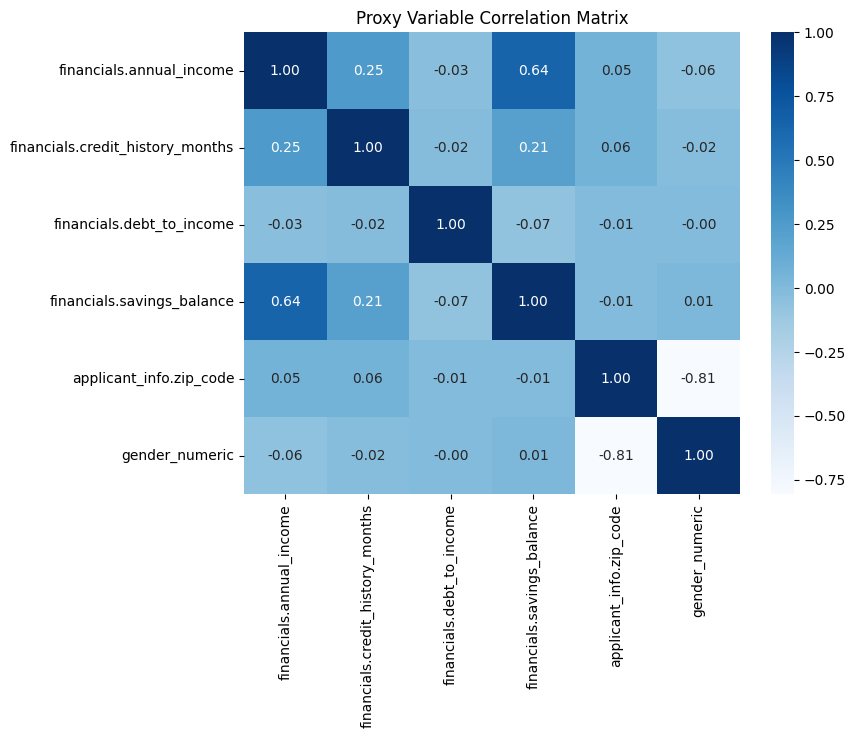

In [47]:
# Convert gender to numeric for correlation
df['gender_numeric'] = df['applicant_info.gender'].map({'Male': 1, 'Female': 0})

# Define potential proxy variables
proxy_candidates = [
    'financials.annual_income',
    'financials.credit_history_months',
    'financials.debt_to_income',
    'financials.savings_balance',
    'applicant_info.zip_code'
]

# Ensure proxy variables are numeric
for col in proxy_candidates:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Replace common non-numeric placeholders with NaN
df = df.replace(["", " ", "NA", "N/A", "--", "null"], pd.NA)

# Create a clean dataset for correlation
corr_df = df[proxy_candidates + ['gender_numeric']].copy()

# Remove rows where ALL proxy values are missing
corr_df = corr_df.dropna(how='all')

# Replace infinite values (if any)
corr_df = corr_df.replace([float('inf'), float('-inf')], pd.NA)


correlation_matrix = corr_df.corr()
display(correlation_matrix)



# Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("Proxy Variable Correlation Matrix")
plt.show()

##### 3.3. Correlation of non-protected attributes with Age

,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,applicant_info.zip_code,age
financials.annual_income,1.000000,0.200644,-0.083376,0.638782,0.024240,0.404607
financials.credit_history_months,0.200644,1.000000,-0.065612,0.151334,0.029668,0.663745
financials.debt_to_income,-0.083376,-0.065612,1.000000,-0.055020,-0.031504,-0.026024
financials.savings_balance,0.638782,0.151334,-0.055020,1.000000,-0.020525,0.283951
applicant_info.zip_code,0.024240,0.029668,-0.031504,-0.020525,1.000000,0.032353
age,0.404607,0.663745,-0.026024,0.283951,0.032353,1.000000


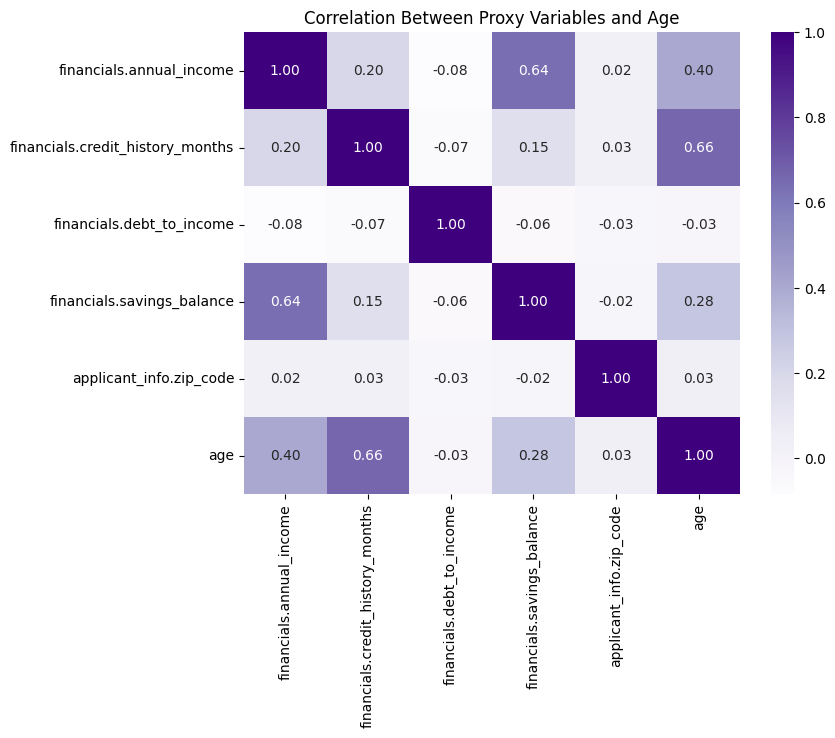

In [48]:
df['dob'] = pd.to_datetime(df['applicant_info.date_of_birth'], errors='coerce')
df['age'] = pd.Timestamp.now().year - df['dob'].dt.year
df['age'] = pd.to_numeric(df['age'], errors='coerce')

proxy_candidates = [
    'financials.annual_income',
    'financials.credit_history_months',
    'financials.debt_to_income',
    'financials.savings_balance',
    'applicant_info.zip_code'
]

# Ensure proxy variables are numeric
for col in proxy_candidates:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Replace common non-numeric placeholders with NaN
df = df.replace(["", " ", "NA", "N/A", "--", "null"], pd.NA)

# Create a clean dataset for correlation
corr_df = df[proxy_candidates + ['gender_numeric']].copy()

# Remove rows where ALL proxy values are missing
corr_df = corr_df.dropna(how='all')

# Replace infinite values (if any)
corr_df = corr_df.replace([float('inf'), float('-inf')], pd.NA)

age_corr_df = df[proxy_candidates + ['age']].dropna(subset=['age'])
display(age_corr_df.corr())

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(age_corr_df.corr(), annot=True, cmap="Purples", fmt=".2f")
plt.title("Correlation Between Proxy Variables and Age")
plt.show()



##### 3.2. Correlation of non-protected attributes with Loan Approval

,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,applicant_info.zip_code,loan_numeric
financials.annual_income,1.000000,0.253524,-0.032381,0.635464,0.054771,0.182719
financials.credit_history_months,0.253524,1.000000,-0.020265,0.207913,0.058949,0.141518
financials.debt_to_income,-0.032381,-0.020265,1.000000,-0.068550,-0.007512,0.007444
financials.savings_balance,0.635464,0.207913,-0.068550,1.000000,-0.007965,0.134527
applicant_info.zip_code,0.054771,0.058949,-0.007512,-0.007965,1.000000,-0.123377
loan_numeric,0.182719,0.141518,0.007444,0.134527,-0.123377,1.000000


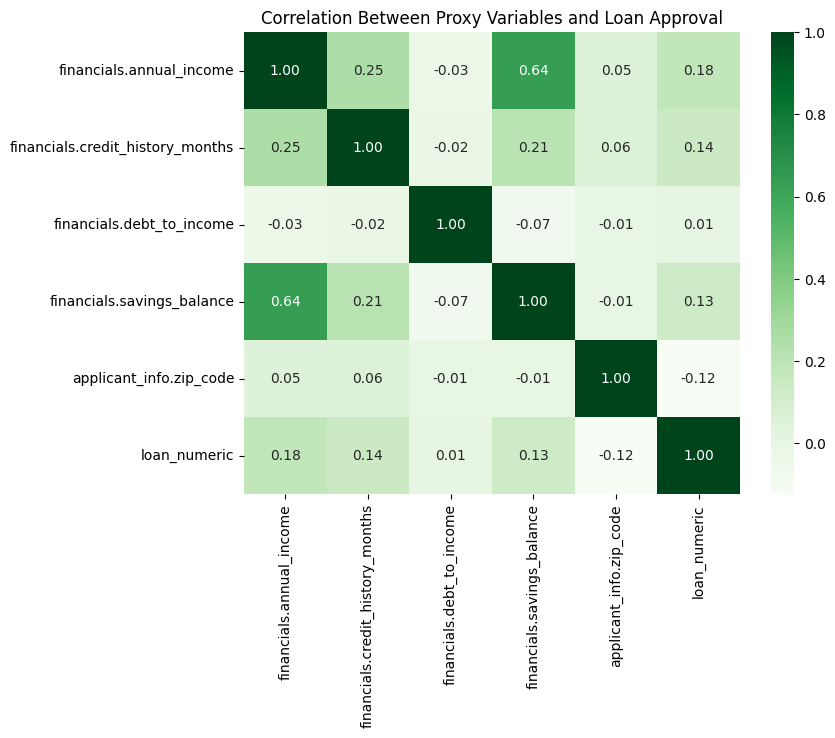

In [50]:
df['loan_numeric'] = df['decision.loan_approved'].astype(int)

proxy_candidates = [
    'financials.annual_income',
    'financials.credit_history_months',
    'financials.debt_to_income',
    'financials.savings_balance',
    'applicant_info.zip_code'
]
for col in proxy_candidates:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
loan_corr_df = df[proxy_candidates + ['loan_numeric']].dropna(subset=['loan_numeric'])
display(loan_corr_df.corr())

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(loan_corr_df.corr(), annot=True, cmap="Greens", fmt=".2f")
plt.title("Correlation Between Proxy Variables and Loan Approval")
plt.show()



